# AG-HYPOPT · Trial 31

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Thirty trials are registered; cell 2 reports `phase = trials` (30/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074), with **trial_30** (0.1083) a very close second. Key facts (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- best (all 0 div): trial_21 0.1074 (0.138), trial_30 0.1083 (0.134), trial_22 0.1095 (0.137), trial_08 0.1099 (0.134), trial_15 0.1103 (0.127), trial_24 0.1108 (0.133), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_18 0.1121 (0.138), trial_09 = trial_20 = trial_25 0.1126, trial_01 = trial_14 = trial_23 0.1127.
- worse: trial_13 0.1132, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_27 0.1149 (0.194), trial_06 = trial_11 0.1188.
- diverging at 1nW T05 (near-optimum travel): trial_29 0.1331, trial_26 0.1368, trial_28 0.1370. Other diverging: trial_17 0.1329, trial_10 0.1975, trial_03 0.1362, trial_04 0.1418, trial_02 0.1449.

State of play: single optimum spike at travel ~0.137-0.138; when a run survives the 1nW T05 cell it delivers ~0.107-0.113, otherwise it scores ~0.13-0.14 via the one diverged cell. Thirteen divergence-free samples now span 0.1074-0.1188. The dominant remaining effect is the sporadic low-count divergence, not any schedule knob. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_31'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (30/5 trials)
ID |     ei | params
 1 | 1.3461 | {"gamma_anneal": 0.4698708728850867, "lr_gamma": 0.443141453291255, "lr_mu": 0.15623036906880342, "mu_anneal": 0.1765301392328813}
 2 | 2.5466 | {"gamma_anneal": 0.45554427374631606, "lr_gamma": 0.4246531410380401, "lr_mu": 0.15933444309762282, "mu_anneal": 0.34224460515994876}
 3 | 2.0160 | {"gamma_anneal": 0.47829140272050197, "lr_gamma": 0.850345761637391, "lr_mu": 0.15581947383640618, "mu_anneal": 0.3417362615732755}
 4 | 3.7603 | {"gamma_anneal": 0.5157520283350054, "lr_gamma": 0.4131123463772112, "lr_mu": 0.1591098615686672, "mu_anneal": 0.3486480702900511}
 5 | 3.1312 | {"gamma_anneal": 0.4869942317349562, "lr_gamma": 0.4649616224576811, "lr_mu": 0.1566927980381211, "mu_anneal": 0.34007627426153025}
 6 | 3.7635 | {"gamma_anneal": 0.4829164003727539, "lr_gamma": 0.4538349616800342, "lr_mu": 0.14628465203141183, "mu_anneal": 0.3479738121025448}
 7 | 1.3432 | {"gamma_anneal": 0.4936111576946922, "lr_gamma": 0.43300558

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (30 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 6: **ei 3.76** — `lr_mu=0.1463`, `mu_anneal=0.3480` (travel **0.121**), `lr_gamma=0.4538`, `gamma_anneal=0.4829`.
- candidate 4: **ei 3.76** — `lr_mu=0.1591`, `mu_anneal=0.3486` (travel **0.131**), `lr_gamma=0.4131`, `gamma_anneal=0.5158`.
- candidate 8: ei 3.70 — `lr_mu=0.1551`, `mu_anneal=0.3514` (travel 0.128), `lr_gamma=0.4108`, `gamma_anneal=0.5230`.
- candidate 5: ei 3.13 — `lr_mu=0.1567`, `mu_anneal=0.3401` (travel 0.130), `lr_gamma=0.4650`.
- candidate 2: ei 2.55 — `lr_mu=0.1593`, `mu_anneal=0.3422` (travel 0.131), `lr_gamma=0.4247`.

Candidates 6 and 4 are tied at the top ei (3.76). They differ in travel: candidate 6 is at 0.121 and candidate 4 at 0.131. The campaign's evidence places the optimum at ~0.137-0.138, with travel 0.120-0.123 (trials 01/09/20) giving ~0.1126-0.1127 and travel 0.127-0.138 giving 0.1074-0.1103. So candidate 4, at travel 0.131, is nearer the productive region than candidate 6 (0.121), and its gamma knobs (`lr_gamma=0.4131`, `gamma_anneal=0.5158`) are in the proven-safe range. On the tied ei, candidate 4 is therefore the better-placed choice. Candidates 8/5/2 are similar near-optimum points at lower ei.

I choose candidate 4 (4 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.5157520283350054, 'lr_gamma': 0.4131123463772112, 'lr_mu': 0.1591098615686672, 'mu_anneal': 0.3486480702900511}
Running  1nW Trans05 ... 

μ 9.39 -> 10.25 | γ 8.5 -> 4.38 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 44.38 | γ 8.5 -> 6.24 | NLL 5.48


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 79.49 | γ 14.1 -> 14.39 | NLL 3.93


Running 3nW Trans100 ... 

μ 175.71 -> 109.60 | γ 14.1 -> 14.04 | NLL 3.65



Total: 9.2 min


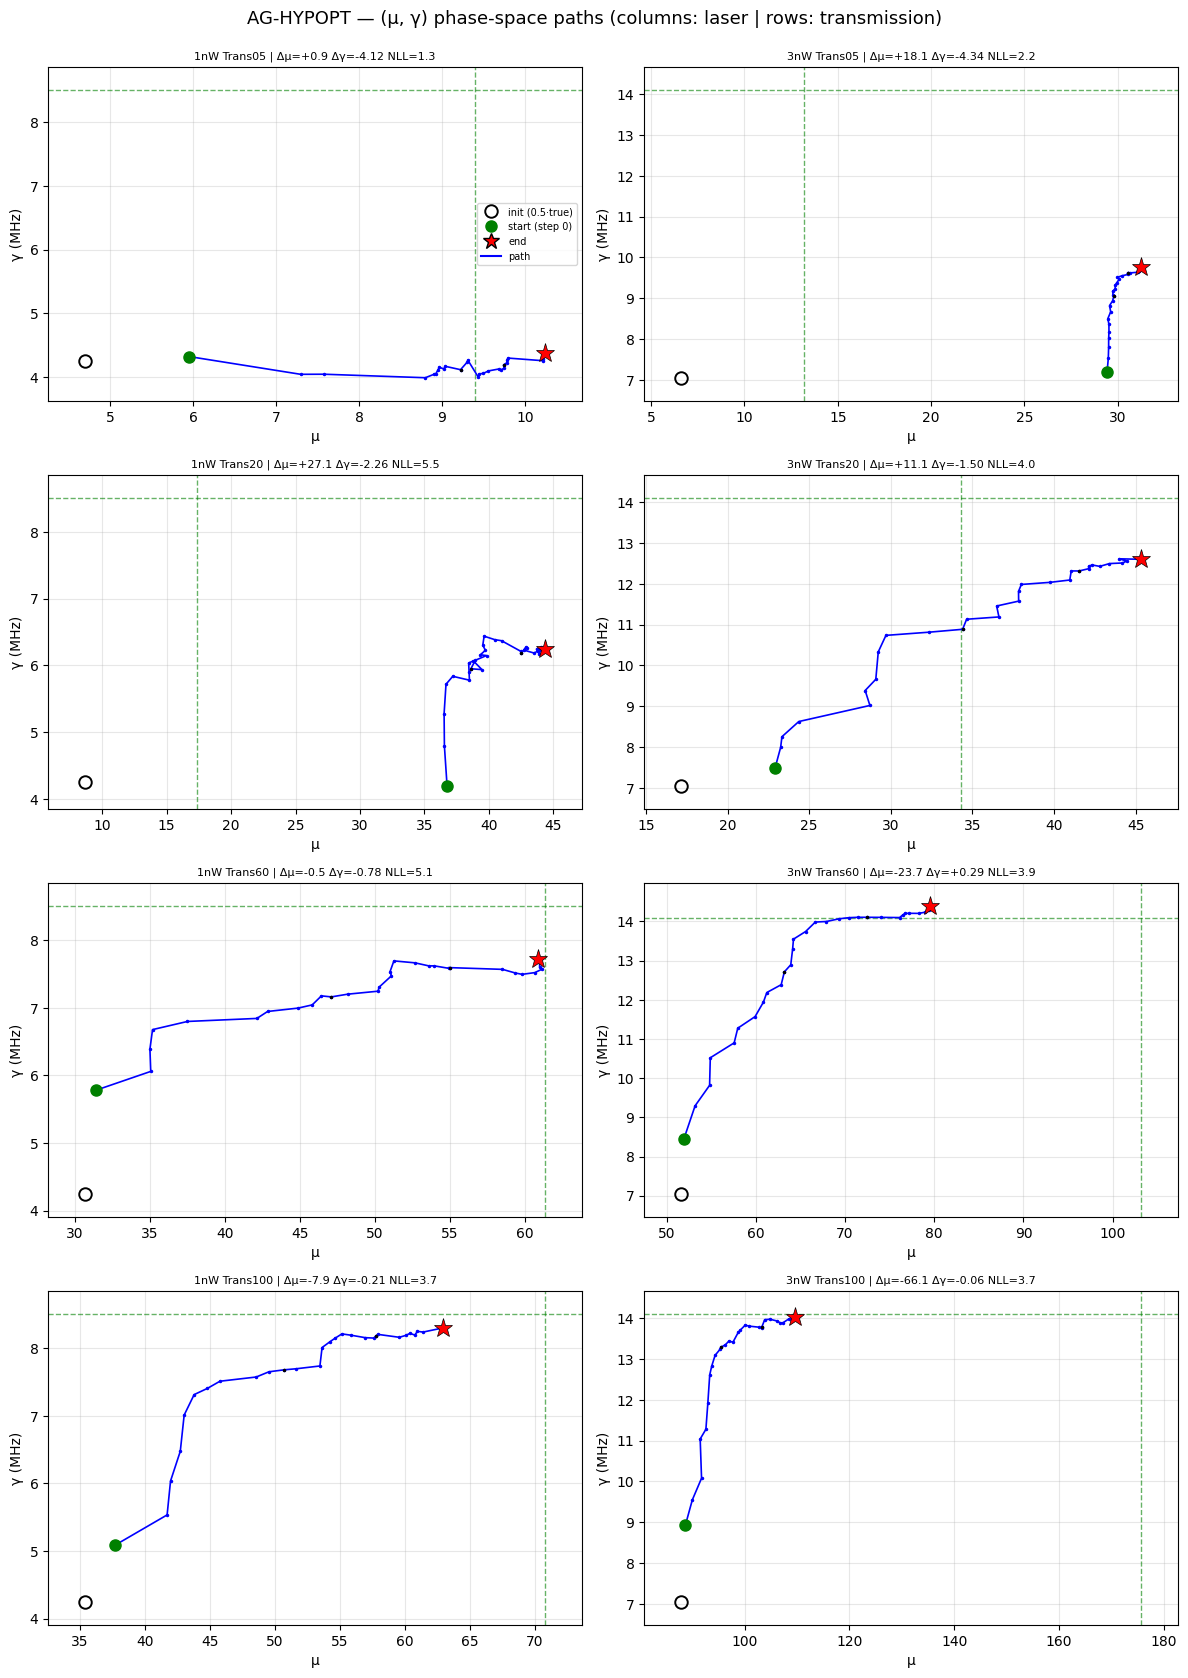

trial finished in 9.2 min
objective = 0.1106 ± 0.0825
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.25    +9.1 |     8.50    4.38   -48.4
1nW Trans20       17.32   44.38  +156.3 |     8.50    6.24   -26.5
1nW Trans60       61.37   60.89    -0.8 |     8.50    7.72    -9.2
1nW Trans100       70.82   62.94   -11.1 |     8.50    8.29    -2.4
3nW Trans05       13.20   31.26  +136.7 |    14.10    9.76   -30.8
3nW Trans20       34.28   45.35   +32.3 |    14.10   12.60   -10.6
3nW Trans60      103.20   79.49   -23.0 |    14.10   14.39    +2.0
3nW Trans100      175.71  109.60   -37.6 |    14.10   14.04    -0.4

weighted objective (T-graded, cap=1.0) = 0.1106 | diverged cells: 0
μ: RMSE 27.784 (rel 76.1%, bias -5.143) | γ: RMSE 2.340 (rel 22.9%, bias -1.620)


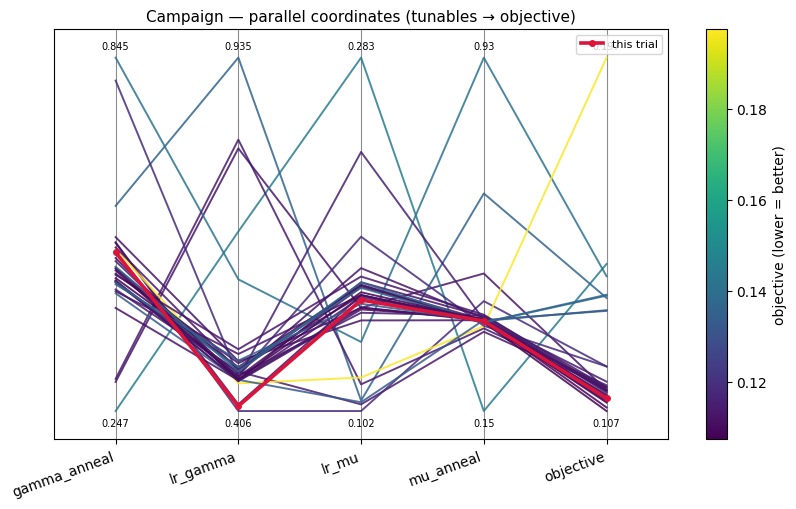

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 31 ran candidate 4 (ei=3.76, tied for top; chosen over the tied candidate 6 because its travel 0.131 is nearer the optimum than candidate 6's 0.121). Config: `lr_mu=0.1591`, `mu_anneal=0.3486` (effective mu travel 0.131), `lr_gamma=0.4131`, `gamma_anneal=0.5158`. It completed in 9.2 min with objective **0.1106 +/- 0.0825** and **0 diverged cells** — sixth-best. Ranking: trial_21 0.1074 < trial_30 0.1083 < trial_22 0.1095 < trial_08 0.1099 < trial_15 0.1103 < **trial_31 0.1106** < trial_24 0.1108 < ...

Aggregate accuracy: **mu rel-RMSE 76.1%** (RMSE 27.78, bias -5.14); **gamma rel-RMSE 22.9%** (RMSE 2.34, bias -1.62).

Per-cell relative errors:
- **mu:** 1nW T05 +9.1%, T20 +156.3%, T60 -0.8%, T100 -11.1% | 3nW T05 +136.7%, T20 +32.3%, T60 -23.0%, T100 -37.6%.
- **gamma:** 1nW T05 -48.4%, T20 -26.5%, T60 -9.2%, T100 -2.4% | 3nW T05 -30.8%, T20 -10.6%, T60 +2.0%, T100 -0.4%.

A textbook divergence-free optimum sample (travel 0.131, safe gamma knobs), landing at 0.1106 — right in the middle of the region's typical band. Nothing unusual: a strong 1nW T60 (-0.8%), the usual mid-T overshoots and 3nW high-T undershoot, and clean gamma at high T. With it, six runs now sit below 0.111 (trial_21 0.1074, trial_30 0.1083, trial_22 0.1095, trial_08 0.1099, trial_15 0.1103, trial_31 0.1106). The picture is stable: the optimum region yields ~0.107-0.111 whenever the 1nW T05 cell survives.

**Summary:** Trial 31 (lr_mu=0.1591, mu_anneal=0.3486, lr_gamma=0.4131, gamma_anneal=0.5158): objective 0.1106 +/- 0.0825 with 0 diverged cells; another divergence-free optimum sample (travel 0.131) landed sixth-best, consistent with the region's typical ~0.107-0.111.
**Key insight:** The optimum keeps delivering 0.107-0.111 when the low-count cell survives (now six sub-0.111 runs), reinforcing that the achievable level with this schedule family is ~0.108 and that all larger objectives come from the sporadic 1nW T05 divergence.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The schedule search has converged to ~0.108 ± 0.003 at travel ~0.13-0.14 with balanced gamma; the only high-value lever left is the divergence itself. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 31 (lr_mu=0.1591, mu_anneal=0.3486, lr_gamma=0.4131, gamma_anneal=0.5158): objective 0.1106 +/- 0.0825 with 0 diverged cells; another divergence-free optimum sample (travel 0.131) landed sixth-best, consistent with the region's typical ~0.107-0.111"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The optimum keeps delivering 0.107-0.111 when the low-count cell survives (now six sub-0.111 runs), reinforcing that the achievable level with this schedule family is ~0.108 and that all larger objectives come from the sporadic 1nW T05 divergence"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_31 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_32.ipynb. Open it and follow its cells from the top.
